In [1]:
import json
from pathlib import Path
from collections import Counter, defaultdict
from sklearn.metrics import cohen_kappa_score

In [2]:
def read_json(path: Path):
    if path.exists():
        with path.open("r") as f:
            data = json.loads(f.read())
            return data
    return None

def clean_annotations(annotations: list):
    annotations = annotations[0:21]
    annotations.pop(14)
    for doc in annotations:
        for raw_ann in doc["annotation"]["raw_annotations"]:
            if not raw_ann["rating"]:
                print("Missing annotation:")
                print(doc)
        for harm_ann in doc["annotation"]["harmonized_annotations"]:
            if not harm_ann["rating"]:
                print("Missing annotation:")
                print(doc)

    return annotations

def get_human_annotations(path):

    annotations = read_json(path)
    annotations = clean_annotations(annotations)

    return annotations


def extract_answer_text(response: str) -> str:
    text = response.strip().lower()

    if "answer:" in text:
        _, suffix = text.split("answer:", 1)
        return suffix.strip(" *:!?.-\n\r\t").capitalize()  # remove common punctuation and whitespace

    return ""  

def get_model_annotations(raw_file, harmonized_file):
    """
    Group raw and harmonized descriptors by document.

    Args:
        raw_file: Path to raw descriptors JSONL file
        harmonized_file: Path to harmonized descriptors JSONL file

    Returns:
        List of dictionaries with grouped descriptors
    """
    annotations = defaultdict(dict)

    # Process raw descriptors
    with open(raw_file, 'r', encoding='utf-8') as f:
        curr_doc = ""
        index = 0
        for line in f:
            data = json.loads(line)
            doc_id = data["example"]["document"]

            # Initialize document entry if new
            if doc_id != curr_doc:
                curr_doc = doc_id
                annotations[curr_doc] = {
                    "annotation": {
                        "raw_annotations": [],
                        "harmonized_annotations": []  # Pre-initialize for harmonized
                    }
                }
                index = 0

            # Extract and store the rating
            rating = extract_answer_text(data["response"])
            annotations[curr_doc]["annotation"]["raw_annotations"].append({
                "index": index,
                "rating": rating
            })
            index += 1

    # Process harmonized descriptors
    with open(harmonized_file, 'r', encoding='utf-8') as f:
        curr_doc = ""
        index = 0
        for line in f:
            data = json.loads(line)
            doc_id = data["example"]["document"]

            # Initialize document entry if not exists (shouldn't happen if files match)
            if doc_id not in annotations:
                annotations[doc_id] = {
                    "annotation": {
                        "raw_annotations": [],
                        "harmonized_annotations": []
                    }
                }

            # Only reset index if this is a new document in this file
            if doc_id != curr_doc:
                curr_doc = doc_id
                index = 0

            # Extract and store the rating
            rating = extract_answer_text(data["response"])
            annotations[curr_doc]["annotation"]["harmonized_annotations"].append({
                "index": index,
                "rating": rating
            })
            index += 1

    # Convert defaultdict to list of dicts with "doc" and "annotation" keys
    result = [
        {
            "doc": doc_id,
            "annotation": annotation_data["annotation"]
        }
        for doc_id, annotation_data in annotations.items()
    ]

    result = result[0:20]
    return result


def read_jsonl(path: Path):
    data = []
    if path.exists():
        with path.open("r") as f:
            for line in f:
                data.append(json.loads(line))

    return data
                
otto_path = Path("../data/annotations/descriptor_annotations_otto.json")
erik_path = Path("../data/annotations/descriptor_annotations_erik.json")
annotations = {
    "otto": get_human_annotations(otto_path),
    "erik": get_human_annotations(erik_path),
    "model": get_model_annotations(Path("../data/annotations/LLM_judgments_raw.jsonl"),
                                    Path("../data/annotations/LLM_judgments_harmonized.jsonl"))
}

# Check data integrity
assert len(annotations["otto"]) == len(annotations["erik"])
assert len(annotations["otto"]) == len(annotations["model"])
for doc_o, doc_e, doc_m in zip(annotations["otto"],annotations["erik"],annotations["model"]):
    assert doc_o["doc_id"] == doc_e["doc_id"]
    assert len(doc_o["annotation"]["raw_annotations"]) == len(doc_m["annotation"]["raw_annotations"])
    if not len(doc_o["annotation"]["harmonized_annotations"]) == len(doc_m["annotation"]["harmonized_annotations"]):
        print(doc_o)
        print(doc_m)
        print(doc_e)

In [3]:
raw_counts = Counter()
harm_counts = Counter()
for doc in annotations["erik"]:
    for raw_ann in doc["annotation"]["raw_annotations"]:
        raw_counts.update([raw_ann["rating"]])
    for harm_ann in doc["annotation"]["harmonized_annotations"]:
        harm_counts.update([harm_ann["rating"]])
        if not harm_ann["rating"]:
            print(doc)

In [4]:
for count in raw_counts.most_common():
    print(count[0], count[1], round(count[1]/raw_counts.total(),2))

Accurate 242 0.74
Mostly accurate 55 0.17
Partially accurate 22 0.07
Mostly inaccurate 8 0.02


In [5]:
for count in harm_counts.most_common():
    print(count[0], count[1], round(count[1]/raw_counts.total(),2))

Accurate 112 0.34
Partially accurate 83 0.25
Mostly accurate 73 0.22
Mostly inaccurate 45 0.14
Inaccurate 13 0.04


In [6]:
collapsed_annotations = {
    "otto": {"raw": [], "harmonized": []},
    "erik": {"raw": [], "harmonized": []},
    "model": {"raw": [], "harmonized": []}
}

for doc_o, doc_e, doc_m in zip(annotations["otto"],annotations["erik"],annotations["model"]):
    collapsed_annotations["otto"]["raw"].extend([desc["rating"] for desc in doc_o["annotation"]["raw_annotations"]])
    collapsed_annotations["erik"]["raw"].extend([desc["rating"] for desc in doc_e["annotation"]["raw_annotations"]])
    collapsed_annotations["model"]["raw"].extend([desc["rating"] for desc in doc_m["annotation"]["raw_annotations"]])
    collapsed_annotations["otto"]["harmonized"].extend([desc["rating"] for desc in doc_o["annotation"]["harmonized_annotations"]])
    collapsed_annotations["erik"]["harmonized"].extend([desc["rating"] for desc in doc_e["annotation"]["harmonized_annotations"]])
    collapsed_annotations["model"]["harmonized"].extend([desc["rating"] for desc in doc_m["annotation"]["harmonized_annotations"]])


In [17]:
from sklearn.metrics import cohen_kappa_score, f1_score, confusion_matrix
from itertools import combinations
import numpy as np
from collections import Counter

def combine_labels(labels):
    combined_labels = []
    for i,label in enumerate(labels):
        if label == "Mostly accurate":
            combined_labels.append("Accurate")
        elif label == "Mostly inaccurate":
            combined_labels.append("Inaccurate")
        else:
            combined_labels.append(label)

    assert "Mostly accurate" not in combined_labels
    assert "Mostly inaccurate" not in combined_labels

    return combined_labels


def process_labels(labels, combine):
    if combine:
        labels = combine_labels(labels)
        l2i = {
            "Accurate": 1,
            "Partially accurate": 3,
            "Inaccurate": 5
        }
        labels = [l2i[label] for label in labels]
    else:
        l2i = {
            "Accurate": 1,
            "Mostly accurate": 2,
            "Partially accurate": 3,
            "Mostly inaccurate": 4,
            "Inaccurate": 5
        }
        labels = [l2i[label] for label in labels]

    return labels
        

def mean_absolute_difference(annotations1, annotations2, only_disagreements=False):
    """Calculate the mean absolute difference between two sets of ordinal annotations."""
    diffs = np.abs(np.array(annotations1) - np.array(annotations2))
    if only_disagreements:
        diffs = diffs[diffs > 0]
        if len(diffs) == 0:
            return 0
    return np.mean(diffs)

def most_common_disagreements(annotations1, annotations2):
    disagreements = []
    for ann1, ann2 in zip(annotations1, annotations2):
        if ann1 != ann2:
            disagreements.append(np.abs(ann1-ann2))

    return Counter(disagreements)

def calculate_kappas(annotations, combine=False):
    annotators = list(annotations.keys())
    results = {}

    for annotation_type in ["raw", "harmonized"]:
        results[annotation_type] = {}

        # Get all pairs of annotators
        for a1, a2 in combinations(annotators, 2):
            ann1 = annotations[a1][annotation_type]
            ann2 = annotations[a2][annotation_type]

            # Change labels to idx for weighted kappa
            ann1 = process_labels(ann1, combine)
            ann2 = process_labels(ann2, combine)

            if len(ann1) == 0 or len(ann2) == 0:
                results[annotation_type][f"{a1}_vs_{a2}"] = None
                continue

            try:
                cm = confusion_matrix(ann1, ann2)
                kappa = cohen_kappa_score(ann1, ann2, weights="quadratic")
                f1 = f1_score(ann1, ann2, average='weighted')
                MAD = mean_absolute_difference(ann1, ann2)
                MCD = most_common_disagreements(ann1, ann2)
                results[annotation_type][f"{a1}_vs_{a2}"] = {"kappa": round(kappa,3), "f1": round(f1,3), "CM": cm, "MAD": round(MAD, 3), "MCD": MCD.most_common()}
            except ValueError as e:
                results[annotation_type][f"{a1}_vs_{a2}"] = f"Error: {str(e)}"

    return results

kappas = calculate_kappas(collapsed_annotations, combine=False)
for desc_type, scores in kappas.items():
    print(desc_type)
    for pair, score in scores.items():
        print(pair)
        print("kappa:", score["kappa"])
        print("f1:", score["f1"])
        print("MAD:", score["MAD"])
        print("MCD:", score["MCD"])
        print("Conf. matrix:")
        print(score["CM"])
        print()
    print("===========")

raw
otto_vs_erik
kappa: 0.427
f1: 0.774
MAD: 0.401
MCD: [(1, 62), (2, 23), (3, 5), (4, 2)]
Conf. matrix:
[[229  47  15   1   0]
 [  7   4   1   2   0]
 [  3   1   1   1   0]
 [  1   0   2   1   0]
 [  2   3   3   3   0]]

otto_vs_model
kappa: 0.493
f1: 0.853
MAD: 0.312
MCD: [(2, 17), (1, 15), (4, 11), (3, 3)]
Conf. matrix:
[[273   1   9   0   9]
 [ 12   1   0   0   1]
 [  5   0   0   0   1]
 [  2   0   0   0   2]
 [  2   0   2   0   7]]

erik_vs_model
kappa: 0.369
f1: 0.636
MAD: 0.474
MCD: [(1, 57), (2, 27), (3, 8), (4, 5)]
Conf. matrix:
[[229   2   6   0   5]
 [ 47   0   3   0   5]
 [ 15   0   1   0   6]
 [  3   0   1   0   4]
 [  0   0   0   0   0]]

harmonized
otto_vs_erik
kappa: 0.578
f1: 0.458
MAD: 0.807
MCD: [(1, 115), (2, 57), (3, 10), (4, 1)]
Conf. matrix:
[[84 40 25  2  0]
 [17 16 21 11  2]
 [ 7  9 21  8  0]
 [ 3  5  7 14  3]
 [ 1  3  9 10  8]]

otto_vs_model
kappa: 0.432
f1: 0.406
MAD: 1.046
MCD: [(1, 71), (2, 59), (3, 24), (4, 20)]
Conf. matrix:
[[125   2  12   0  12]
 [ 38 

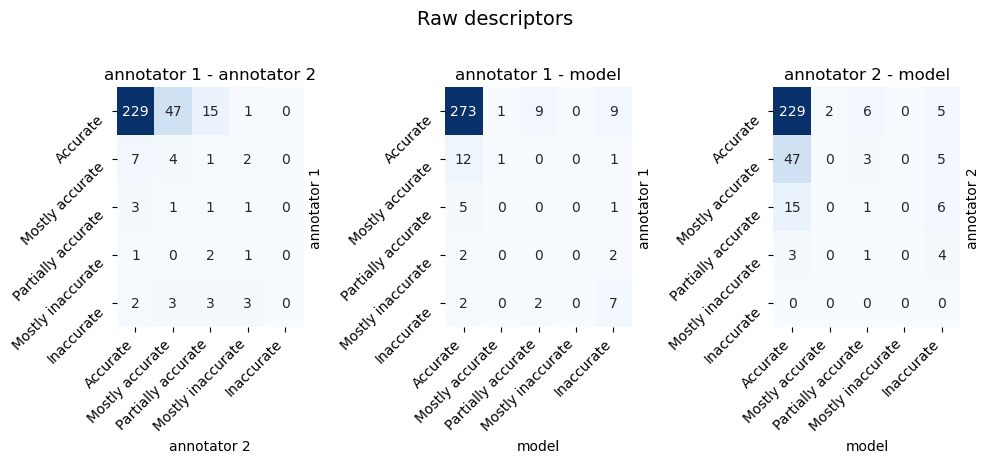

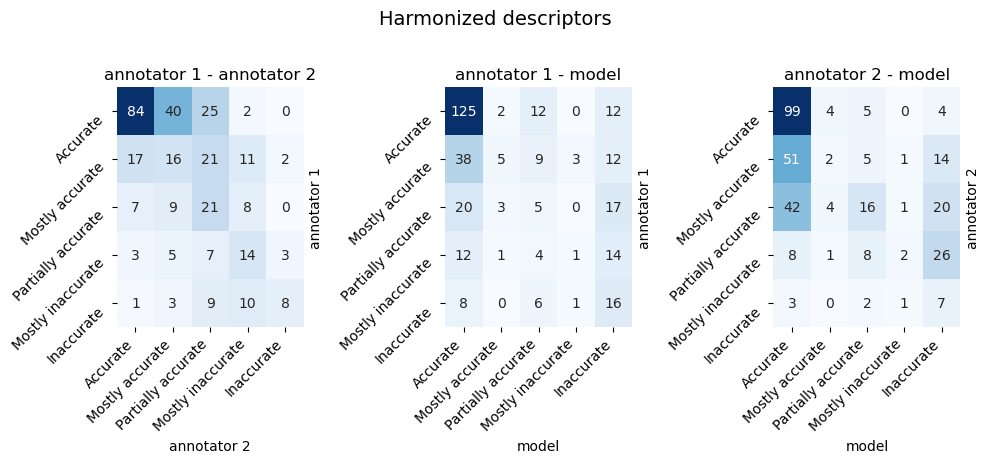

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion_matrices(results, combine=False, figsize=(10, 4.5), cmap="Blues", annot=True, fmt=".0f"):
    """
    Plot confusion matrices as heatmaps for all annotator pairs.

    Args:
        results: Dictionary containing the results from calculate_kappas.
        combine: Boolean indicating if labels were combined.
        figsize: Tuple specifying the figure size.
        cmap: Colormap for the heatmap.
        annot: Boolean to show annotations in the heatmap.
        fmt: Format string for annotations.
    """
    annotators = list(results["raw"].keys())
    num_pairs = len(annotators)

    # Determine label names based on combine flag
    if combine:
        label_names = ["Accurate", "Partially accurate", "Inaccurate"]
    else:
        label_names = ["Accurate", "Mostly accurate", "Partially accurate", "Mostly inaccurate", "Inaccurate"]

    for annotation_type in ["raw", "harmonized"]:
        plt.figure(figsize=figsize)
        plt.suptitle(f"{annotation_type.capitalize()} descriptors", y=1.02, fontsize=14)

        for i, pair in enumerate(annotators):
            ann1 = pair.split("_")[0]
            ann2 = pair.split("_")[-1]
            if ann1 == "otto":
                ann1 = "annotator 1"
            if ann1 == "erik":
                ann1 = "annotator 2"
            if ann2 == "erik":
                ann2 = "annotator 2"
            cm = results[annotation_type][pair]["CM"]

            if cm is not None:
                ax = plt.subplot(1, num_pairs, i+1)
                plt.subplot(1, num_pairs, i+1)
                sns.heatmap(cm, annot=annot, fmt=fmt, cmap=cmap,
                            xticklabels=label_names, yticklabels=label_names, 
                            cbar=False, ax=ax)
                plt.title(f"{ann1} - {ann2}")
                plt.xlabel(ann2)
                # Move y-axis to the right side
                ax.yaxis.set_label_position("right")
                ax.set_ylabel(ann1)
                
                ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
                ax.set_yticklabels(ax.get_yticklabels(), rotation=45, ha='right',va='top')

        plt.tight_layout()
        plt.savefig(f"../data/annotations/annotation_confusion_matrices_{annotation_type}.png", dpi=300, bbox_inches="tight")
        plt.show()

# Example usage:
plot_confusion_matrices(kappas, combine=False)

In [42]:
confusion_matrix([1,2,3], [2,2,2])

array([[0, 1, 0],
       [0, 1, 0],
       [0, 1, 0]])